# pyWENDy Script
Demonstration notebook for OLS, IRLS, and Sparsify solvers on test ODE systems.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import time

import OLS_Solver as OLS
import IRLS_Solver as IRLS
import SparsifyDynamicsSolver as SDS
import Simulation as Sim

In [2]:
def rhs_fun(features, params, x):
    nstates = len(x)
    x = tuple(x)
    dx = np.zeros(nstates)
    for i in range(nstates):
        dx[i] = np.sum([f(*x)*p for f, p in zip(features[i], params[i])])
    return dx


def lorenz():
    features = [
        [lambda x, y, z: y, lambda x, y, z: x],
        [lambda x, y, z: x, lambda x, y, z: x*z, lambda x, y, z: y],
        [lambda x, y, z: x*y, lambda x, y, z: z]
    ]
    params = [np.array([10, -10]), np.array([28, -1, -1]), np.array([1, -8/3])]

    x0 = np.array([-8, 10, 27])
    t =  np.linspace(0, 10, 501)
    tspan = (t[0], t[-1])
    tol_ode = 1e-15
    rhs_p = lambda t, x: rhs_fun(features, params, x)
    true_vec = np.concatenate(params).reshape(-1, 1)

    sol = solve_ivp(rhs_p, t_span=tspan, y0=x0, t_eval=t, rtol=tol_ode, atol=tol_ode)
    x = sol.y.T
    t = sol.t
    return x, t, params, x0, true_vec, features, rhs_p


def logistic_growth():
    features = [
        [lambda x: x, lambda x: x**2]
    ]
    params = [np.array([ 1, -1])]
    x0 = np.array([ 0.01 ])
    t =  np.linspace(0, 10, 501)
    tspan = (t[0], t[-1])
    tol_ode = 1e-15

    rhs_p = lambda t, x: rhs_fun(features, params, x)
    true_vec = np.concatenate(params).reshape(-1, 1)

    sol = solve_ivp(rhs_p, t_span=tspan, y0=x0, t_eval=t, rtol=tol_ode, atol=tol_ode)
    x = sol.y.T
    t = sol.t
    return x, t, params, x0, true_vec, features, rhs_p


def lorenz_overcomplete():
    """Lorenz system with an overcomplete degree-2 monomial library.
    
    The library for each equation contains all 10 monomials up to degree 2
    in (x, y, z):  [1, x, y, z, x^2, xy, xz, y^2, yz, z^2].
    
    The true coefficients are mostly zeros, with the nonzero entries
    corresponding to the standard Lorenz parameters (sigma=10, rho=28, beta=8/3).
    This is the natural test case for sparsification: recover the few active
    terms from a large candidate library.
    """
    # Full degree-2 monomial library (same 10 functions for every equation)
    lib = [
        lambda x, y, z: np.ones_like(x),  # 0: 1
        lambda x, y, z: x,                 # 1: x
        lambda x, y, z: y,                 # 2: y
        lambda x, y, z: z,                 # 3: z
        lambda x, y, z: x**2,              # 4: x^2
        lambda x, y, z: x*y,               # 5: xy
        lambda x, y, z: x*z,               # 6: xz
        lambda x, y, z: y**2,              # 7: y^2
        lambda x, y, z: y*z,               # 8: yz
        lambda x, y, z: z**2,              # 9: z^2
    ]
    # Each equation gets the same 10-term library
    features = [list(lib), list(lib), list(lib)]

    # True sparse coefficient vectors (length 10 each, mostly zeros)
    # dx/dt = sigma*(y - x)       = -10*x + 10*y
    # dy/dt = rho*x - y - x*z     = 28*x - y - xz
    # dz/dt = x*y - beta*z        = xy - (8/3)*z
    w_true_1 = np.array([0, -10, 10, 0, 0, 0, 0, 0, 0, 0])    # eq 1
    w_true_2 = np.array([0, 28, -1, 0, 0, 0, -1, 0, 0, 0])    # eq 2
    w_true_3 = np.array([0, 0, 0, -8/3, 0, 1, 0, 0, 0, 0])    # eq 3

    params_oc = [w_true_1, w_true_2, w_true_3]
    true_vec = np.concatenate(params_oc).reshape(-1, 1)

    # Generate clean trajectory using the true sparse dynamics
    x0 = np.array([-8, 10, 27])
    t = np.linspace(0, 10, 501)
    tspan = (t[0], t[-1])
    tol_ode = 1e-15
    rhs_p = lambda t, x: rhs_fun(features, params_oc, x)

    sol = solve_ivp(rhs_p, t_span=tspan, y0=x0, t_eval=t, rtol=tol_ode, atol=tol_ode)
    x = sol.y.T
    t = sol.t
    return x, t, params_oc, x0, true_vec, features, rhs_p


# Select which system to run
x, t, params, x0, true_vec, features, rhs_p = lorenz()

c:\Users\Scotty\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


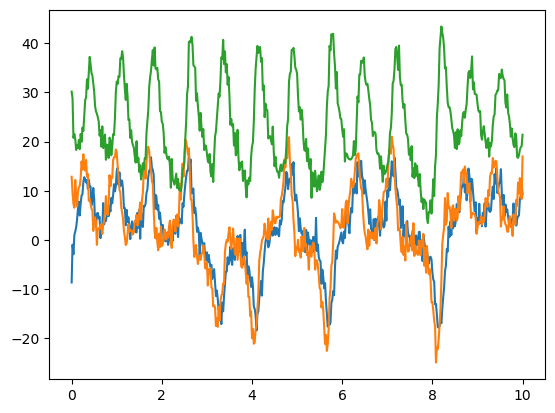

In [3]:
def gen_noise(U_exact, sigma_NR, noise_dist, noise_alg):
    if noise_alg == 0:  # additive
        stdv = np.square(np.sqrt(np.mean(np.square(U_exact))))
    elif noise_alg == 1:  # multiplicative
        stdv = 1
    dims = U_exact.shape
    if noise_dist == 0:  # white noise
        if sigma_NR > 0:
            sigma = sigma_NR * np.sqrt(stdv)
        else:
            sigma = -sigma_NR
        noise = np.random.normal(0, sigma, dims)
    elif noise_dist == 1:  # uniform noise
        if sigma_NR > 0:
            sigma = np.sqrt(3 * np.square(sigma_NR) * stdv)
        else:
            sigma = -sigma_NR
        noise = sigma * (2 * np.random.rand(*dims) - 1)
    if noise_alg == 0:  # additive
        U = U_exact + noise
    elif noise_alg == 1:  # multiplicative
        U = U_exact * (1 + noise)
    noise_ratio_obs = np.linalg.norm(U - U_exact) / np.linalg.norm(U_exact)
    return U, noise, noise_ratio_obs, sigma

subsamp = 1
tobs = t[::subsamp]
xobs = x[::subsamp, :]
M, nstates = xobs.shape

# Add noise
noise_ratio = 0.1
noise_dist = 0
noise_alg = 0
xobs_n, noise, _, sigma = gen_noise(xobs, noise_ratio, noise_dist, noise_alg)
plt.plot(tobs, xobs_n)

In [6]:
#IRLS - SL
start = time.time()
IRLS_SL_model = IRLS.IRLS_Solver(features, xobs_n, tobs, type_tf=0, toggle_SVD=False, gap=1, 
                                 p=16, S=1, mu=[1, 2, 1], diag_reg=1e-10, Mtilde=None, 
                                 trunc=0, radius=None, type_rad=0)
IRLS_SL_model.fit_IRLS()
runtime = time.time() - start

sl_simulation = Sim.Simulation(features=features, w_hat=IRLS_SL_model.w_hat, x0=xobs[0], t=tobs)
u_hat = sl_simulation.simulate()

E_2 = np.linalg.norm(IRLS_SL_model.w_hat - true_vec)/np.linalg.norm(true_vec)*100
E_FS = np.linalg.norm(u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print('Radius:', IRLS_SL_model.radius)
print('Param error:',  f"{E_2:.3f}%")
print('FS error:', f"{E_FS:.3f}%")
print('Runtime:', f"{runtime:.3f}s")

c:\Users\Scotty\anaconda3\Lib\site-packages\scipy\integrate\_ivp\common.py:47: UserWarning: At least one element of `rtol` is too small. Setting `rtol = np.maximum(rtol, 2.220446049250313e-14)`.
  warn("At least one element of `rtol` is too small. "


oops
Radius: [22]
Param error: 3.988%
FS error: 73.750%
Runtime: 1.395s


In [7]:
#IRLS - MG
start = time.time()
IRLS_MG_model = IRLS.IRLS_Solver(features, xobs_n, tobs, type_tf=0, toggle_SVD=True, gap=1, 
                                 p=16, S=1, mu=[1, 2, 1], diag_reg=1e-10, Mtilde=None, 
                                 trunc=0, radius=None, type_rad=1)
IRLS_MG_model.fit_IRLS()
runtime = time.time() - start

mg_simulation = Sim.Simulation(features=features, w_hat=IRLS_MG_model.w_hat, x0=xobs[0], t=tobs)
MG_u_hat = mg_simulation.simulate()

MG_E_2 = np.linalg.norm(IRLS_MG_model.w_hat - true_vec)/np.linalg.norm(true_vec)*100
MG_E_FS = np.linalg.norm(MG_u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print('Radius:', IRLS_MG_model.radius)
print('Param error:',  f"{MG_E_2:.3f}%")
print('FS error:', f"{MG_E_FS:.3f}%")
print('Runtime:', f"{runtime:.3f}s")

Radius: [ 9 18 36 72]
Param error: 4.418%
FS error: 70.265%
Runtime: 5.038s


In [8]:
#OLS - SL
start = time.time()
OLS_SL_model = OLS.OLS_Solver(features, xobs_n, tobs, type_tf=0, toggle_SVD=False, gap=1, 
                              p=16, S=1, mu=[1, 2, 1], Mtilde=None, diag_reg=1e-10, 
                              trunc=0, radius=None, type_rad=0)
OLS_SL_model.fit_OLS()
runtime = time.time() - start

ols_sl_sim = Sim.Simulation(features=features, w_hat=OLS_SL_model.w_hat, x0=xobs[0], t=tobs)
u_hat = ols_sl_sim.simulate()

E_2 = np.linalg.norm(OLS_SL_model.w_hat - true_vec)/np.linalg.norm(true_vec)*100
E_FS = np.linalg.norm(u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print('Radius:', OLS_SL_model.radius)
print('Param error:',  f"{E_2:.3f}%")
print('FS error:', f"{E_FS:.3f}%")
print('Runtime:', f"{runtime:.3f}s")

Radius: [22]
Param error: 3.895%
FS error: 64.870%
Runtime: 0.291s


In [9]:
#OLS - MG
start = time.time()
OLS_MG_model = OLS.OLS_Solver(features, xobs_n, tobs, type_tf=0, toggle_SVD=True, gap=1, 
                              p=16, S=1, mu=[1, 2, 1], Mtilde=None, diag_reg=1e-10, 
                              trunc=0, radius=None, type_rad=1)
OLS_MG_model.fit_OLS()
runtime = time.time() - start

ols_mg_sim = Sim.Simulation(features=features, w_hat=OLS_MG_model.w_hat, x0=xobs[0], t=tobs)
u_hat = ols_mg_sim.simulate()

E_2 = np.linalg.norm(OLS_MG_model.w_hat - true_vec)/np.linalg.norm(true_vec)*100
E_FS = np.linalg.norm(u_hat - xobs, 'fro')/np.linalg.norm(xobs, 'fro')*100

print('Radius:', OLS_MG_model.radius)
print('Param error:',  f"{E_2:.3f}%")
print('FS error:', f"{E_FS:.3f}%")
print('Runtime:', f"{runtime:.3f}s")

oops
Radius: [ 9 18 36 72]
Param error: 7.322%
FS error: 60.433%
Runtime: 4.962s


---
## SparsifyDynamicsSolver Test — Overcomplete Lorenz
The cell below generates Lorenz data using the overcomplete degree-2 monomial library
(10 candidate terms per equation, 30 total), adds noise, and runs the sequential
thresholding sparsifier to recover the true sparse structure.

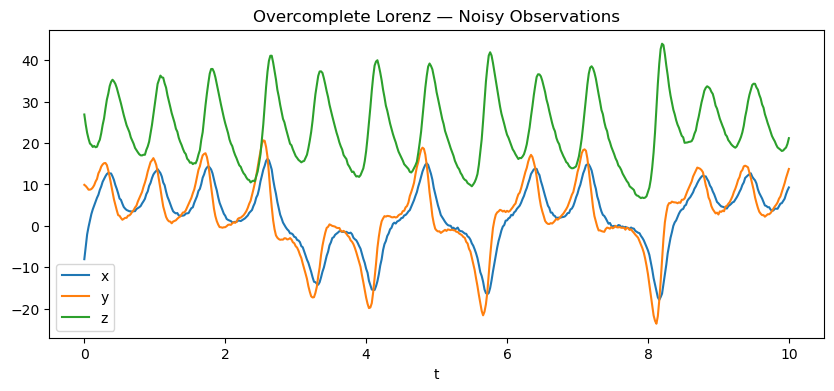

In [10]:
# Generate overcomplete Lorenz data
x_oc, t_oc, params_oc, x0_oc, true_vec_oc, features_oc, rhs_p_oc = lorenz_overcomplete()

# Subsample and add noise
subsamp_oc = 1
tobs_oc = t_oc[::subsamp_oc]
xobs_oc = x_oc[::subsamp_oc, :]

noise_ratio_oc = 0.01
xobs_n_oc, noise_oc, _, sigma_oc = gen_noise(xobs_oc, noise_ratio_oc, 0, 0)

plt.figure(figsize=(10, 4))
plt.plot(tobs_oc, xobs_n_oc)
plt.title('Overcomplete Lorenz — Noisy Observations')
plt.xlabel('t')
plt.legend(['x', 'y', 'z'])
plt.show()

In [25]:
# Build and run SparsifyDynamicsSolver on the overcomplete Lorenz system
start = time.time()
sparse_model = SDS.SparsifyDynamicsSolver(
    features_oc, xobs_n_oc, tobs_oc,
    type_tf=0, toggle_SVD=False, gap=1,
    p=16, S=1, mu=[1, 2, 1], Mtilde=None,
    diag_reg=1e-10, trunc=0, radius=None, type_rad=0
)

# Run sparsification: lam_val controls the threshold, gamma adds Tikhonov regularisation
lam_val = 0.6
gamma = 0.05
w_hat_sparse, Xi_list, its_list = sparse_model.sparsifyDynamics(lam_val, gamma=gamma)
runtime = time.time() - start

# Simulate forward using the recovered sparse coefficients
sparse_sim = Sim.Simulation(features=features_oc, w_hat=w_hat_sparse, x0=xobs_oc[0], t=tobs_oc)
u_hat_sparse = sparse_sim.simulate()

# Compute errors
E_2_sparse = np.linalg.norm(w_hat_sparse - true_vec_oc) / np.linalg.norm(true_vec_oc) * 100
E_FS_sparse = np.linalg.norm(u_hat_sparse - xobs_oc, 'fro') / np.linalg.norm(xobs_oc, 'fro') * 100

print('=== SparsifyDynamicsSolver Results ===')
print(f'Radius: {sparse_model.radius}')
print(f'Param error:  {E_2_sparse:.3f}%')
print(f'FS error:     {E_FS_sparse:.3f}%')
print(f'Runtime:      {runtime:.3f}s')
print(f'Iterations per equation: {its_list}')

oops
=== SparsifyDynamicsSolver Results ===
Radius: [20]
Param error:  0.343%
FS error:     37.103%
Runtime:      0.305s
Iterations per equation: [3, 3, 2]


In [26]:
# Print recovered vs true coefficients for inspection
lib_names = ['1', 'x', 'y', 'z', 'x^2', 'xy', 'xz', 'y^2', 'yz', 'z^2']
eq_labels = ['dx/dt', 'dy/dt', 'dz/dt']

print('\n=== Coefficient Comparison (True vs Recovered) ===')
for ii in range(3):
    print(f'\n--- {eq_labels[ii]} ---')
    print(f'{"Term":>6s}  {"True":>10s}  {"Recovered":>10s}')
    for jj in range(10):
        w_true_jj = true_vec_oc[ii*10 + jj, 0]
        w_hat_jj = w_hat_sparse[ii*10 + jj, 0]
        marker = '  <--' if abs(w_true_jj) > 1e-12 else ''
        print(f'{lib_names[jj]:>6s}  {w_true_jj:10.4f}  {w_hat_jj:10.4f}{marker}')


=== Coefficient Comparison (True vs Recovered) ===

--- dx/dt ---
  Term        True   Recovered
     1      0.0000      0.0000
     x    -10.0000     -9.9180  <--
     y     10.0000      9.9358  <--
     z      0.0000      0.0000
   x^2      0.0000      0.0000
    xy      0.0000      0.0000
    xz      0.0000      0.0000
   y^2      0.0000      0.0000
    yz      0.0000      0.0000
   z^2      0.0000      0.0000

--- dy/dt ---
  Term        True   Recovered
     1      0.0000      0.0000
     x     28.0000     28.0214  <--
     y     -1.0000     -1.0175  <--
     z      0.0000      0.0000
   x^2      0.0000      0.0000
    xy      0.0000      0.0000
    xz     -1.0000     -1.0010  <--
   y^2      0.0000      0.0000
    yz      0.0000      0.0000
   z^2      0.0000      0.0000

--- dz/dt ---
  Term        True   Recovered
     1      0.0000      0.0000
     x      0.0000      0.0000
     y      0.0000      0.0000
     z     -2.6667     -2.6587  <--
   x^2      0.0000      0.0000
    x

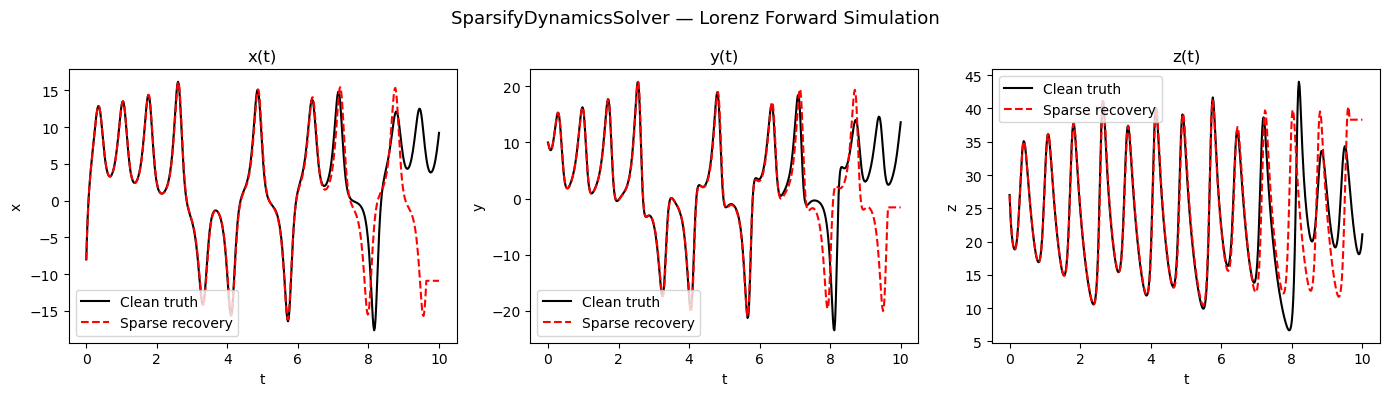

In [27]:
# Plot forward simulation comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
state_labels = ['x', 'y', 'z']
for ii in range(3):
    axes[ii].plot(tobs_oc, xobs_oc[:, ii], 'k-', label='Clean truth', linewidth=1.5)
    axes[ii].plot(tobs_oc, u_hat_sparse[:, ii], 'r--', label='Sparse recovery', linewidth=1.5)
    axes[ii].set_xlabel('t')
    axes[ii].set_ylabel(state_labels[ii])
    axes[ii].set_title(f'{state_labels[ii]}(t)')
    axes[ii].legend()
plt.suptitle('SparsifyDynamicsSolver — Lorenz Forward Simulation', fontsize=13)
plt.tight_layout()
plt.show()